# Atividade Vendas no Brasil
#### Capacitação Analytica - Python para ciência de dados


## Entregável 1 - NumPy

In [14]:
import numpy as np
import pandas as pd

arquivo = pd.read_csv("/content/vendas_brasil_1.csv")
df = pd.DataFrame(arquivo)


#### Tratando

In [15]:
df = df.dropna()
df.head(5)

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False
5,2023-12-02,12,Recife,Loja Física,Livros,Machine Learning,Carla Mendes,Bronze,81.84,60.25,...,9,0.1,923.86,23.59,2.99,16.0,False,True,True,False
6,2022-01-21,1,Manaus,Site Web,Livros,Python para Dados,Henrique Dias,Bronze,124.28,83.82,...,6,24.0,728.61,38.10,1.99,3.0,False,True,True,False


#### a) Criando arrays

In [16]:
 #visualizando prévia do df
preco_unitario = np.array(df['preco_unitario'])
custo_unitario = np.array(df['custo_unitario'])
quantidade = np.array(df['quantidade'])
desconto = np.array(df['desconto_pct'])
receita_total = np.array(df['receita_total'])
frete = np.array(df['frete'])

preco_unitario, custo_unitario, quantidade, desconto, receita_total, frete

(array([ 739.39,  145.86,  133.92, ...,   55.15,  197.09, 1057.41]),
 array([561.75,  88.53, 107.25, ...,  36.94, 167.23, 870.69]),
 array([10, 11,  1, ...,  7,  7,  4]),
 array([ 5.2,  0.6, 19.5, ...,  0. , 10.9, 10. ]),
 array([6933.48, 1592.43,  107.64, ...,  384.44, 1960.18, 3795.73]),
 array([ 8.68, 20.49, 22.89, ..., 85.35, 30.99, 27.23]))

#### b) Cálculos com operações vetorizada

In [17]:
valor_bruto_venda = preco_unitario * quantidade
valor_desconto = valor_bruto_venda * desconto
custo_total = custo_unitario * quantidade
lucro_estimado = receita_total - custo_total

print("Valor Bruto da Venda:", valor_bruto_venda)
print("------------------------------------------------------------------------")
print("Valor do Desconto:", valor_desconto)
print("------------------------------------------------------------------------")
print("Custo Total:", custo_total)
print("------------------------------------------------------------------------")
print("Lucro Estimado:", lucro_estimado)


Valor Bruto da Venda: [7393.9  1604.46  133.92 ...  386.05 1379.63 4229.64]
------------------------------------------------------------------------
Valor do Desconto: [38448.28    962.676  2611.44  ...     0.    15037.967 42296.4  ]
------------------------------------------------------------------------
Custo Total: [5617.5   973.83  107.25 ...  258.58 1170.61 3482.76]
------------------------------------------------------------------------
Lucro Estimado: [1.31598e+03 6.18600e+02 3.90000e-01 ... 1.25860e+02 7.89570e+02
 3.12970e+02]


#### c) Máscaras booleanas

In [18]:
# vendas com receita acima da média

media_receita = np.mean(receita_total)
mascara_acima_media = receita_total > media_receita

receitas_altas = receita_total[mascara_acima_media]

qnt_acima_media = np.sum(mascara_acima_media)

print("Quantidade de vendas com receita acima da média:", qnt_acima_media)
print("Receitas acima da média:", receitas_altas)

Quantidade de vendas com receita acima da média: 7740
Receitas acima da média: [6933.48 2167.48 7945.96 ... 3369.62 1960.18 3795.73]


In [19]:
# vendas com prejuízo

mascara_prejuizo = lucro_estimado < 0
qnt_vendas_prejuizo = np.sum(mascara_prejuizo)

id = np.arange(len(df))
id_prejuizo = id[mascara_prejuizo]

print("Quantidade de vendas com prejuízo:", qnt_vendas_prejuizo)
print("IDs das vendas com prejuízo:", id_prejuizo)

Quantidade de vendas com prejuízo: 1817
IDs das vendas com prejuízo: [    6    21    68 ... 31432 31439 31459]


In [20]:
# vendas com desconto alto

limite_desconto = 25.00
mascara_desconto_alto = desconto > limite_desconto

qnt_desconto_alto = np.sum(mascara_desconto_alto)
id_desconto_alto = id[mascara_desconto_alto]
print("Quantidade de vendas com desconto alto:", qnt_desconto_alto)
print("IDs das vendas com desconto alto:", id_desconto_alto)


Quantidade de vendas com desconto alto: 1950
IDs das vendas com desconto alto: [   21    30    31 ... 31427 31434 31442]


#### d) Agregações

In [21]:
# receita média
receita_media = np.mean(receita_total)

# maior receita
maior_receita = np.max(receita_total)

# menor receita
menor_receita = np.min(receita_total)

# lucro medio
lucro_medio = np.mean(lucro_estimado)

# quantidade de vendas com prejuizo
vendas_com_prejuizo = np.sum(lucro_estimado < 0)

print("Receita média:", receita_media)
print("Maior receita:", maior_receita)
print("Menor receita:", menor_receita)
print("Lucro médio:", lucro_medio)
print("Quantidade de vendas com prejuízo:", vendas_com_prejuizo)



Receita média: 1889.0613278667684
Maior receita: 58430.28
Menor receita: 3.7
Lucro médio: 511.91847381133994
Quantidade de vendas com prejuízo: 1817


##### Conclusões
Nota-se que a receita das vendas, em média, gira em torno de R$ 1889, mas existe uma enorme variação dos dados, dado que a menor receita é de R$ 3,70 é a maior sendo de R$ 58.430,28, obtendo picos extremos. Embora o lucro médio seja positivo, em torno de R$512,00, existe um volume significativo de vendas com prejuízo, indicando que políticas de desconto ou custos de frete precisam de revisão em certos cenários.

## Entregável 2

In [22]:
# carregando novamente o df para executar as alterações popostas nesse exercício, pois o df original foi alterado com a exclusão de linhas com valores nulos.
arquivo_2= pd.read_csv("/content/vendas_brasil_1.csv")

df_carregado_2 = pd.DataFrame(arquivo_2)

#### a)

In [23]:
# exploracao inicial
df_carregado_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  object 
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  object 
 3   canal_venda         37567 non-null  object 
 4   categoria           37617 non-null  object 
 5   produto             37617 non-null  object 
 6   vendedor            37577 non-null  object 
 7   fidelidade_cliente  37617 non-null  object 
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  praz

In [24]:
df_carregado_2.describe()

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000


In [25]:
df_carregado_2.shape

(37617, 21)

In [26]:
df_carregado_2.isna().sum()

,0
data_venda,0
mes,0
cidade,0
canal_venda,50
categoria,0
produto,0
vendedor,40
fidelidade_cliente,0
preco_unitario,0
custo_unitario,0


#### b) Limpeza e tratamento

In [27]:
df_carregado_2['data_venda'] = pd.to_datetime(df_carregado_2['data_venda'], format='mixed', dayfirst=True)
# fiquei em duvida no uso do dayfirst=true, pois a data de venda está em formato misto, com a maioia ano/mes/dia, mas com poucas instancias em dia/mes/ano. Utilizei tentando dirar a ambiguidade, mas não sei se é a melhor forma de tratar.
df_carregado_2['data_venda'].head(5)

,data_venda
0,2022-04-13
1,2023-03-12
2,2022-09-28
3,2022-04-17
4,2022-03-13


In [28]:
# padronizando a coluna fidelidade_cliente para que todas as palavras comecem com letra maiuscula
df_carregado_2['fidelidade_cliente'] = df_carregado_2['fidelidade_cliente'].str.title()
df_carregado_2['fidelidade_cliente'].head(5)

# padronizando a coluna SiteWeb
df_carregado_2['canal_venda'] = df_carregado_2['canal_venda'].str.title().str.replace('Siteweb', 'Site Web')

# Removendo acentos de todas as colunas categóricas
# Pesquisei alguma forma para remover acentos de todas as colunas de texto do dataset.
# Identificando as colunas de texto
colunas_categoricas = df_carregado_2.select_dtypes(include=['object']).columns

# Iterando sobre cada coluna encontrada
for coluna in colunas_categoricas:
    df_carregado_2[coluna] = (
        df_carregado_2[coluna]
        .astype(str)
        .str.normalize('NFKD')
        .str.encode('ascii', errors='ignore')
        .str.decode('utf-8')
    )

print(f"Acentos removidos com sucesso das colunas: {list(colunas_categoricas)}")

Acentos removidos com sucesso das colunas: ['cidade', 'canal_venda', 'categoria', 'produto', 'vendedor', 'fidelidade_cliente']


In [29]:
# Para as variáveis categóricas sem informação, preenchi com 'Desconhecido'
df_carregado_2['canal_venda'] = df_carregado_2['canal_venda'].fillna('Desconhecido')
df_carregado_2['vendedor'] = df_carregado_2['vendedor'].fillna('Desconhecido')

# Preenchi com zero interpretando que a ausencia de valor pra frete significa frete gratuito, ou seja, frete = 0
df_carregado_2['frete'] = df_carregado_2['frete'].fillna(0)

# Para as avaliações de clientes, preencher com 0 implicaria diretamente na média de nota, então escolhi preencher com a mediana das notas, que é uma medida de tendência central mais robusta a outliers.
mediana_avaliacao = df_carregado_2['avaliacao_cliente'].median()
df_carregado_2['avaliacao_cliente'] = df_carregado_2['avaliacao_cliente'].fillna(mediana_avaliacao)

# Para o prazo de entrega segui a mesma lógica
mediana_prazo_entrega = df_carregado_2['prazo_entrega_dias'].median()
df_carregado_2['prazo_entrega_dias'] = df_carregado_2['prazo_entrega_dias'].fillna(mediana_prazo_entrega)

# Margem percentual faltante preenchida com a média
media_margem = df_carregado_2['margem_pct'].mean()
df_carregado_2['margem_pct'] = df_carregado_2['margem_pct'].fillna(media_margem)

# Verificando se restou algum nulo
print("Dados faltantes após a limpeza:")
print(df_carregado_2.isna().sum()[df_carregado_2.isna().sum() > 0]) # Só imprime se for maior que 0

Dados faltantes após a limpeza:
Series([], dtype: int64)


#### c) Criação de novas colunas

In [30]:
# 1. Ano da venda
df_carregado_2['ano_venda'] = df_carregado_2['data_venda'].dt.year

# 2. Lucro total
df_carregado_2['lucro_total'] = df_carregado_2['receita_total'] - (df_carregado_2['custo_unitario'] * df_carregado_2['quantidade'])

# faixa receita: olha para cada valor de receita (x) e o classifica
df_carregado_2['faixa_receita'] = df_carregado_2['receita_total'].apply(
    lambda x: 'Alta' if x > 5000 else ('Média' if x >= 1000 else 'Baixa')
)

print(df_carregado_2[['data_venda', 'ano_venda', 'receita_total', 'lucro_total', 'faixa_receita']].head())

  data_venda  ano_venda  receita_total  lucro_total faixa_receita
0 2022-04-13       2022        6933.48      1315.98          Alta
1 2023-03-12       2023         930.28       254.53         Baixa
2 2022-09-28       2022        1058.50       198.90         Média
3 2022-04-17       2022        1592.43       618.60         Média
4 2022-03-13       2022         107.64         0.39         Baixa


#### d) Filtros

In [31]:
# 1) Quais vendas tiveram devolução?

devolucao_vendas = df_carregado_2[df_carregado_2['devolucao'] == True]

print("\n--- 1. Vendas Devolvidas ---")
print(f"Total de registros encontrados: {len(devolucao_vendas)}")
print(devolucao_vendas[['data_venda', 'produto', 'devolucao']].head())

# 2) Qual a média de lucro por ano?

media_lucro_ano = df_carregado_2.groupby('ano_venda')['lucro_total'].mean().reset_index()
print("\n--- 2. Média de Lucro por Ano ---")
print(media_lucro_ano)

# 3) Qual a média de avaliação por canal de venda?
media_avaliacao_canal = df_carregado_2.groupby('canal_venda')['avaliacao_cliente'].mean().reset_index()
print("\n--- 3. Média de Avaliação por Canal de Venda ---")
print(media_avaliacao_canal)


--- 1. Vendas Devolvidas ---
Total de registros encontrados: 3532
   data_venda       produto  devolucao
1  2023-03-12      Camiseta       True
2  2022-09-28         Tenis       True
7  2023-09-07  Mel Organico       True
18 2023-10-24      Camiseta       True
21 2023-05-07    Smartwatch       True

--- 2. Média de Lucro por Ano ---
   ano_venda  lucro_total
0       2022   508.880788
1       2023   517.399985

--- 3. Média de Avaliação por Canal de Venda ---
   canal_venda  avaliacao_cliente
0   App Mobile           3.926250
1  Loja Fisica           3.919811
2  Marketplace           3.929920
3     Site Web           3.914026
4   Televendas           3.887517
5          nan           3.832000


#### e) Agrupamentos com groupby

In [32]:
# 1. Quais categorias tiveram maior receita
receita_por_categoria = df_carregado_2.groupby('categoria')['receita_total'].sum()

# ordenando de maior para o menor
receita_por_categoria = receita_por_categoria.sort_values(ascending=False)

print("--- 1. Receita Total por Categoria ---")
print(receita_por_categoria.head(3))

# 2. Qual canal de venda teve maior quantidade de vendas (produtos vendidos)?
qtd_por_canal = df_carregado_2.groupby('canal_venda')['quantidade'].sum().sort_values(ascending=False)

print("\n--- 2. Quantidade de Produtos Vendidos por Canal ---")
print(qtd_por_canal.head(3))

# 3. Qual cidade teve maior receita?
receita_por_cidade = df_carregado_2.groupby('cidade')['receita_total'].sum().sort_values(ascending=False)

print("\n--- 3. Receita Total por Cidade ---")
print(receita_por_cidade.head(3))

--- 1. Receita Total por Categoria ---
categoria
Eletronicos    45017479.88
Esportes       11567480.75
Vestuario       6780473.93
Name: receita_total, dtype: float64

--- 2. Quantidade de Produtos Vendidos por Canal ---
canal_venda
Site Web       85091
App Mobile     83839
Loja Fisica    56705
Name: quantidade, dtype: int64

--- 3. Receita Total por Cidade ---
cidade
Recife       7638412.70
Manaus       7435641.08
Fortaleza    7224144.20
Name: receita_total, dtype: float64


#### f) Merge

In [39]:
# Padronizando a coluna cidade
df_carregado_2['cidade'] = df_carregado_2['cidade'].str.strip().str.title()
correcoes_cidades = {
    'Sp': 'São Paulo', 'Sao Paulo': 'São Paulo', 'S. Paulo': 'São Paulo',
    'Rj': 'Rio De Janeiro', 'Rio': 'Rio De Janeiro',
    'Bh': 'Belo Horizonte', 'B. Horizonte': 'Belo Horizonte',
    'Curtiba': 'Curitiba', 'Slavador': 'Salvador'
}
df_carregado_2['cidade'] = df_carregado_2['cidade'].replace(correcoes_cidades)


# Criando a tabela auxiliar
dados_regioes = {
    'cidade': [
        'São Paulo', 'Rio De Janeiro', 'Belo Horizonte',
        'Curitiba', 'Porto Alegre',
        'Salvador', 'Recife', 'Fortaleza',
        'Goiania',
        'Manaus'
    ],
    'regiao': [
        'Sudeste', 'Sudeste', 'Sudeste',
        'Sul', 'Sul',
        'Nordeste', 'Nordeste', 'Nordeste',
        'Centro-Oeste',
        'Norte'
    ]
}
df_regioes = pd.DataFrame(dados_regioes)


# Fazendo Merge
df_merge = pd.merge(df_carregado_2, df_regioes, on='cidade', how='left')


# Análise: Receita Total por Região
receita_por_regiao = df_merge.groupby('regiao')['receita_total'].sum().sort_values(ascending=False)

print("--- Receita Total por Região ---")
print(receita_por_regiao)

--- Receita Total por Região ---
regiao
Nordeste        21822979.62
Sudeste         20657776.22
Sul             14041603.24
Norte            7459161.23
Centro-Oeste     7178113.69
Name: receita_total, dtype: float64


#### Conclusões


A partir dos filtros e dos agrupamentos feitos, foi possível tirar as seguintes conclusões:
1. A categoria eletrônicos apresenta a maior receita total, correspondente a aproximadamente R$ 45 milhoes, o que evidencia o alto ticket médio desse setor
2. O Site Web foi o canal responsável pelo maior volume de escoamento, com mais de 85 mil unidades vendidas
3. Recife se destacou como a cidade de maior faturamento, gerando mais de R$ 7,6 milhões em receita para a empresa.
4. A região Nordestina apresentou a maior receita total em comparação com as demais.

## Entregável 3

#### a) Gráfico de barras

In [45]:
df_tratado = df_merge.copy()


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt


#### a) Gráfico de Barras


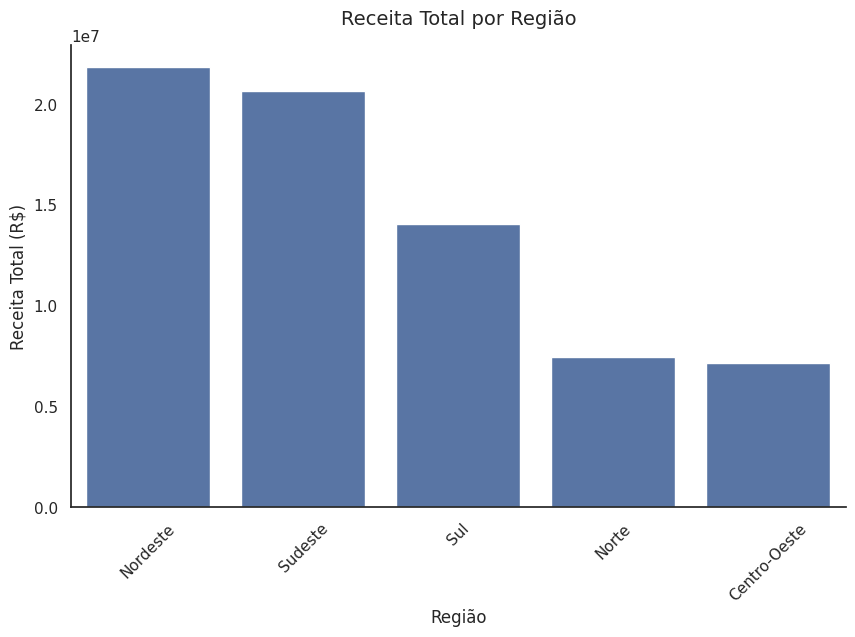

In [49]:
plt.figure(figsize=(10, 6))

# Transformando a Series em DataFrame na hora de passar para o Seaborn
sns.barplot(data=receita_por_regiao.reset_index(), x='regiao', y='receita_total', color='#4C72B0')

# Acabamentos
plt.title('Receita Total por Região', fontsize=14, pad=15)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Receita Total (R$)', fontsize=12)
plt.xticks(rotation=45)
sns.despine()
plt.show()


Como analisado anteriormente, temos o Nordeste e Sudeste como líderes de faturamento por regiões. O gráfico em barras ajuda a ter uma representação visual da disparidade de faturamento entre as regiões. Dessa forma, ao ver a discrepância entre os líderes, as regiões Norte e CO apesentam uma possível margem para expansão comercial.

#### b) Gráfico de Linha

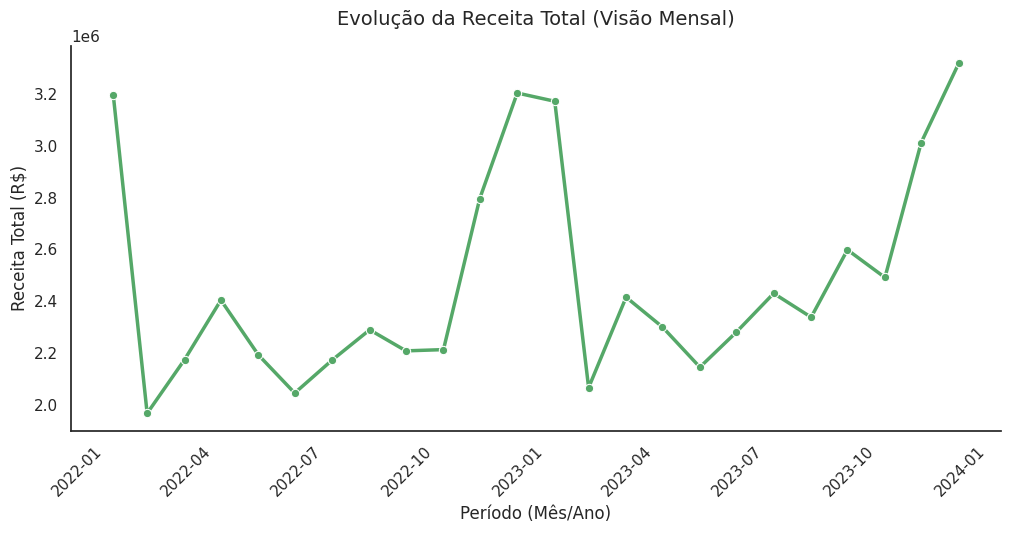

In [52]:
df['data_venda'] = pd.to_datetime(df['data_venda'], format='mixed', dayfirst=True)

plt.figure(figsize=(12, 5))


receita_tempo = df.set_index('data_venda').resample('ME')['receita_total'].sum().reset_index()

sns.lineplot(data=receita_tempo, x='data_venda', y='receita_total', linewidth=2.5, marker='o', color='#55A868')

plt.title('Evolução da Receita Total (Visão Mensal)', fontsize=14, pad=15)
plt.xlabel('Período (Mês/Ano)', fontsize=12)
plt.ylabel('Receita Total (R$)', fontsize=12)
plt.xticks(rotation=45)
sns.despine()
plt.show()

Com o gráfico de linha, é possível identificar visualmente os vales e os picos de faturamento ao longo do ano, evidenciando os períodos de maior aquecimento das vendas (como as altas temporadas). Dessa forma, podemos identificar que o mês de janeiro configura um período de alta temporada para vendas.

#### c) Gráfico de Dispersão


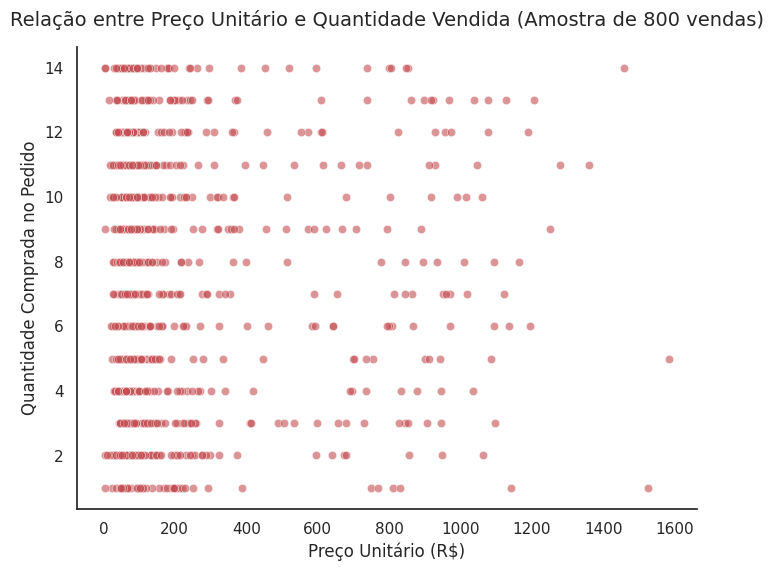

In [54]:
plt.figure(figsize=(8, 6))

# Extraindo uma amostra
df_amostra = df.sample(n=800, random_state=42)

sns.scatterplot(data=df_amostra, x='preco_unitario', y='quantidade', alpha=0.6, color='#C44E52')

# Acabamentos
plt.title('Relação entre Preço Unitário e Quantidade Vendida (Amostra de 800 vendas)', fontsize=14, pad=15)
plt.xlabel('Preço Unitário (R$)', fontsize=12)
plt.ylabel('Quantidade Comprada no Pedido', fontsize=12)
sns.despine()
plt.show()

Podemos análisar a relação preço X quantidade comprada, onde vemos que produtos com preço unitário mais baixo tendem a apresentar picos maiores nas quantidades compradas em um único pedido, indicando compras em atacado ou de itens de baixo valor agregado.

#### d) Heat Map

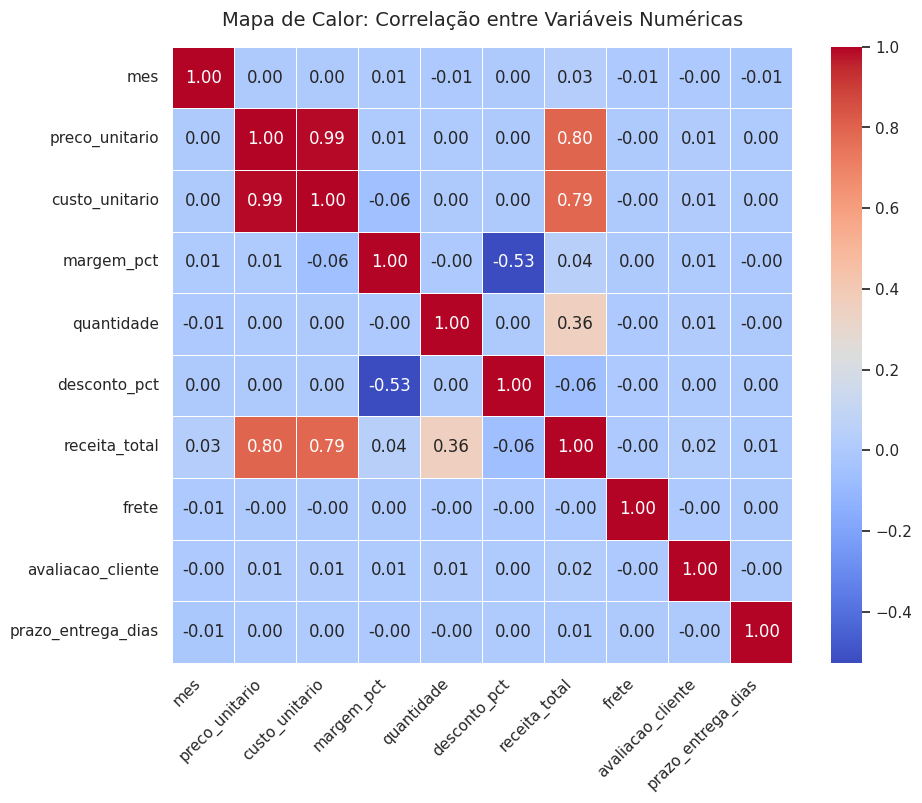

In [55]:
plt.figure(figsize=(10, 8))

colunas_numericas = df.select_dtypes(include=['float64', 'int64', 'int32'])
matriz_corr = colunas_numericas.corr()

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)


plt.title('Mapa de Calor: Correlação entre Variáveis Numéricas', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

O heatmap revela a matriz de correlação das variáveis do dataset. Cores mais quentes e valores próximos a 1 (ou -1) indicam forte associação linear. Nota-se, por exemplo, a forte correlação natural entre a Quantidade ou Preço Unitário e o cálculo do Custo Total, enquanto variáveis logísticas(prazo de entrega) demonstram pouca influência sobre o valor gasto pelo cliente.